In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/cleaned_goodreads_books_dataset.csv")
df.head()

,id,title,series,description,pages,publicationDate,language,rating,ratings,imageURL,genres,amazonLink,ISBN,author,popularReviews
0,49014714,2 Book Collection Set: Conversations with Frie...,NaN,Please Note That The Following Individual Book...,0,2019-01-01,English,3.99,740,https://m.media-amazon.com/images/S/compressed...,['Fiction'],http://www.amazon.com/gp/product/9123926058/re...,9789123926053.0,"{'name': 'Sally Rooney', 'about': 'Sally Roone...","[{'user': {'name': 'Lucy Mckenzie', 'imageURL'..."
1,195854281,3 Book Collection Set: Beautiful World Where A...,NaN,1,0,NaN,English,3.49,35,https://m.media-amazon.com/images/S/compressed...,['Fiction'],https://www.amazon.com/gp/product/B0DJYP1RFC/r...,9780678456934.0,"{'name': 'Sally Rooney', 'about': 'Sally Roone...",[]
2,63063437,4 Book Taylor Jenkins Reid Collection: Malibu ...,NaN,Please Note That The Following Individual Book...,1504,2022-01-01,English,3.89,46,https://m.media-amazon.com/images/S/compressed...,['Fiction'],http://www.amazon.com/gp/product/9123471182/re...,9789123471188.0,"{'name': 'Taylor Jenkins Reid', 'about': 'Tayl...","[{'user': {'name': 'Avani ✨', 'imageURL': 'htt..."
3,39987393,A Book on the Table: Flash Fiction,NaN,This year's story collection includes flash fi...,50,2018-01-01,English,3.75,88,https://m.media-amazon.com/images/S/compressed...,"['Short Stories', 'Fiction', 'Flash Fiction']",http://www.amazon.com/gp/product/099844992X/re...,9780998449920,"{'name': 'Celeste Ng', 'about': ""Celeste Ng is...","[{'user': {'name': 'Drew', 'imageURL': 'https:..."
4,5326,A Christmas Carol,NaN,"'If I had my way, every idiot who goes around ...",184,1999-09-23,English,4.09,914833,https://m.media-amazon.com/images/S/compressed...,"['Classics', 'Fiction', 'Christmas', 'Fantasy'...",https://www.amazon.com/gp/product/B071ZKZBWR/r...,9781561797462,"{'name': 'Charles Dickens', 'about': 'Charles ...",[]


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               724 non-null    int64  
 1   title            724 non-null    str    
 2   series           307 non-null    str    
 3   description      716 non-null    str    
 4   pages            724 non-null    int64  
 5   publicationDate  705 non-null    str    
 6   language         706 non-null    str    
 7   rating           724 non-null    float64
 8   ratings          724 non-null    int64  
 9   imageURL         717 non-null    str    
 10  genres           724 non-null    str    
 11  amazonLink       724 non-null    str    
 12  ISBN             554 non-null    str    
 13  author           724 non-null    str    
 14  popularReviews   724 non-null    str    
dtypes: float64(1), int64(3), str(11)
memory usage: 85.0 KB


In [4]:
df.describe()

,id,pages,rating,ratings
count,7.240000e+02,724.000000,724.000000,7.240000e+02
mean,5.279180e+07,364.219613,3.916961,1.940814e+05
std,6.895645e+07,620.220253,0.358704,6.573712e+05
min,3.040000e+02,0.000000,0.000000,0.000000e+00
25%,1.787171e+06,128.000000,3.720000,1.413000e+03
50%,2.865059e+07,320.000000,3.900000,1.273550e+04
75%,5.874433e+07,400.000000,4.120000,1.136975e+05
max,2.426931e+08,10358.000000,5.000000,9.799364e+06


In [5]:
df.isnull().sum()

id                   0
title                0
series             417
description          8
pages                0
publicationDate     19
language            18
rating               0
ratings              0
imageURL             7
genres               0
amazonLink           0
ISBN               170
author               0
popularReviews       0
dtype: int64

In [6]:
df = df[~df['title'].str.contains('collection|set', case=False, na=False)]

In [7]:
df.shape

(700, 15)

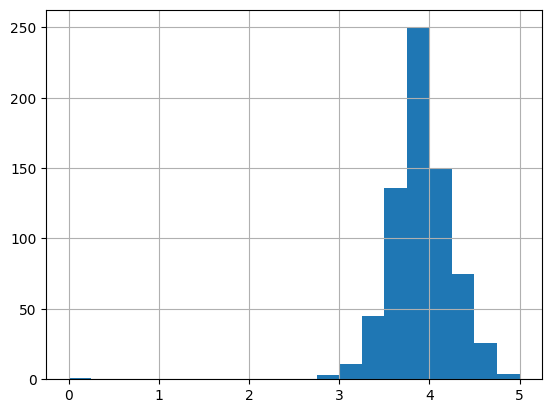

In [8]:
import matplotlib.pyplot as plt

df['rating'].hist(bins=20)
plt.show()

In [9]:
df.sort_values(by="ratings", ascending=False).head(10)

,id,title,series,description,pages,publicationDate,language,rating,ratings,imageURL,genres,amazonLink,ISBN,author,popularReviews
531,2767052,The Hunger Games,"{'title': 'The Hunger Games', 'self_position':...",Winning means fame and fortune. Losing means c...,374,2008-10-14,English,4.35,9799364,https://m.media-amazon.com/images/S/compressed...,"['Young Adult', 'Dystopia', 'Fiction', 'Fantas...",https://www.amazon.com/gp/product/B002MQYOFW/r...,9780439023481,"{'name': 'Suzanne Collins', 'about': 'Libraria...","[{'user': {'name': 'Hannah Azerang', 'imageURL..."
640,56916837,To Kill a Mockingbird,"{'title': 'To Kill a Mockingbird', 'self_posit...","One of the best-loved stories of all time, To ...",323,2021-02-01,English,4.26,6817208,https://m.media-amazon.com/images/S/compressed...,"['Classics', 'Fiction', 'Historical Fiction', ...",https://www.amazon.com/gp/product/B00K0OI42W/r...,NaN,"{'name': 'Harper Lee', 'about': ""Nelle Harper ...","[{'user': {'name': 'Jon', 'imageURL': 'https:/..."
523,41733839,The Great Gatsby,NaN,Alternate covers of this ISBN can be found her...,180,2018-04-01,English,3.93,5852887,https://m.media-amazon.com/images/S/compressed...,"['Classics', 'Fiction', 'School', 'Historical ...",https://www.amazon.com/gp/product/B0CTHPCP33/r...,NaN,"{'name': 'F. Scott Fitzgerald', 'about': 'Fran...","[{'user': {'name': 'Nataliya', 'imageURL': 'ht..."
251,62627512,It Ends with Us,"{'title': 'It Ends with Us', 'self_position': ...",A special hardcover collector’s edition of It ...,373,2023-04-18,English,4.09,4536208,https://m.media-amazon.com/images/S/compressed...,"['Romance', 'Fiction', 'Contemporary', 'Collee...",https://www.amazon.com/gp/product/B0176M3U10/r...,NaN,"{'name': 'Colleen Hoover', 'about': ""Internati...","[{'user': {'name': 'Colleen Hoover', 'imageURL..."
122,6148028,Catching Fire,"{'title': 'The Hunger Games', 'self_position':...",Sparks are igniting.\nFlames are spreading.\nA...,391,2009-09-01,English,4.35,4110171,https://m.media-amazon.com/images/S/compressed...,"['Young Adult', 'Dystopia', 'Fiction', 'Fantas...",https://www.amazon.com/gp/product/B003O86FMW/r...,9780439023498,"{'name': 'Suzanne Collins', 'about': 'Libraria...","[{'user': {'name': 'Cara', 'imageURL': 'https:..."
595,32620332,The Seven Husbands of Evelyn Hugo,"{'title': 'Reidverse', 'self_position': ''}",Aging and reclusive Hollywood movie icon Evely...,389,2017-06-13,English,4.40,4012024,https://m.media-amazon.com/images/S/compressed...,"['Fiction', 'Romance', 'Historical Fiction', '...",https://www.amazon.com/gp/product/B01M5IJM2U/r...,9781501139239.0,"{'name': 'Taylor Jenkins Reid', 'about': 'Tayl...","[{'user': {'name': 'Maria', 'imageURL': 'https..."
672,59344312,Verity,NaN,Lowen Ashleigh is a struggling writer on the b...,336,2021-10-05,English,4.29,3708815,https://m.media-amazon.com/images/S/compressed...,"['Thriller', 'Romance', 'Mystery', 'Fiction', ...",http://www.amazon.com/s/ref=x_gr_bb_amazon?tag...,9781538724743,"{'name': 'Colleen Hoover', 'about': ""Internati...","[{'user': {'name': 'Mareeva', 'imageURL': 'htt..."
313,7260188,Mockingjay,"{'title': 'The Hunger Games', 'self_position':...",My name is Katniss Everdeen.\nWhy am I not dea...,390,2010-08-24,English,4.12,3680659,https://m.media-amazon.com/images/S/compressed...,"['Young Adult', 'Dystopia', 'Fiction', 'Fantas...",https://www.amazon.com/gp/product/B003XF1XOQ/r...,9780439023511,"{'name': 'Suzanne Collins', 'about': 'Libraria...","[{'user': {'name': 'Tina', 'imageURL': 'https:..."
248,90202302,Iron Flame,"{'title': 'The Empyrean', 'self_position': '2'}",Everyone expected Violet Sorrengail to die dur...,640,2023-11-07,English,4.36,2502458,https://m.media-amazon.com/images/S/compressed...,"['Fantasy', 'Romance', 'Romantasy', 'Dragons',...",https://www.amazon.com/gp/product/B0C4JMJBNX/r...,9781649374172,"{'name': 'Rebecca Yarros', 'about': 'Rebecca Y...","[{'user': {'name': 'Angie', 'imageURL': 'https..."
658,17788401,Ugly Love,NaN,When Tate Collins meets airline pilo

In [10]:
df[['pages','rating']].corr()

,pages,rating
pages,1.000000,0.140835
rating,0.140835,1.000000


In [13]:
df["magic"] = df["description"].str.contains("magic", case=False, na=False)
df["romance"] = df["description"].str.contains("love", case=False, na=False)
df["murder"] = df["description"].str.contains("murder", case=False, na=False)
df["war"] = df["description"].str.contains("war", case=False, na=False)
df["academy"] = df["description"].str.contains("academy|school", case=False, na=False)

In [14]:
df = df.dropna(subset=["description"])

In [15]:
df.groupby("magic")["rating"].mean()


magic
False    3.901796
True     3.987600
Name: rating, dtype: float64

In [16]:
df.groupby("magic")["ratings"].mean()

magic
False    204703.476048
True     127010.320000
Name: ratings, dtype: float64

In [17]:
trope_counts = df[["magic","romance","murder","war","academy"]].sum()
trope_counts

magic       25
romance    238
murder      44
war        174
academy     57
dtype: int64

In [18]:
df.groupby("magic")["rating"].mean()
df.groupby("romance")["rating"].mean()
df.groupby("murder")["rating"].mean()

murder
False    3.907504
True     3.866364
Name: rating, dtype: float64

In [19]:
df.groupby("magic")["ratings"].mean()

magic
False    204703.476048
True     127010.320000
Name: ratings, dtype: float64

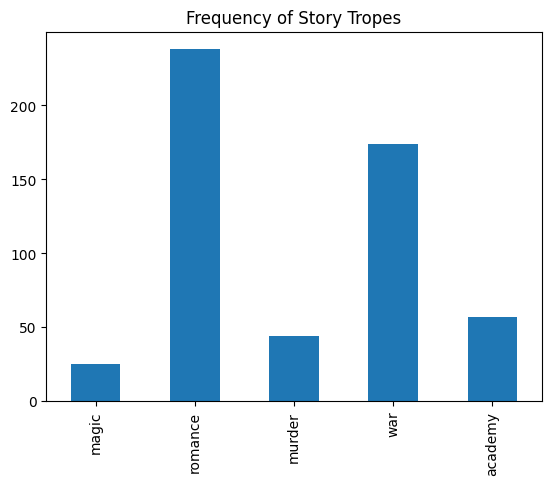

In [20]:
trope_counts.plot(kind="bar")
plt.title("Frequency of Story Tropes")
plt.show()

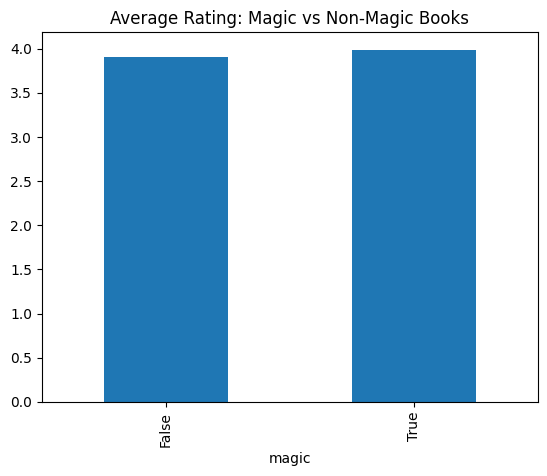

In [21]:
df.groupby("magic")["rating"].mean().plot(kind="bar")
plt.title("Average Rating: Magic vs Non-Magic Books")
plt.show()

In [22]:
trope_summary = pd.DataFrame({
    "trope": ["magic","romance","murder","war","academy"],
    "avg_rating": [
        df[df["magic"]]["rating"].mean(),
        df[df["romance"]]["rating"].mean(),
        df[df["murder"]]["rating"].mean(),
        df[df["war"]]["rating"].mean(),
        df[df["academy"]]["rating"].mean()
    ]
})

trope_summary

,trope,avg_rating
0,magic,3.987600
1,romance,3.908487
2,murder,3.866364
3,war,3.918966
4,academy,3.919123


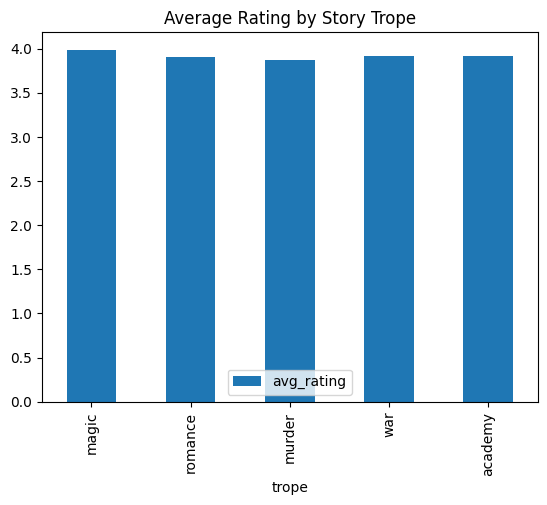

In [23]:
trope_summary.plot(x="trope", y="avg_rating", kind="bar")
plt.title("Average Rating by Story Trope")
plt.show()